Calculate the covariance matrix of the TF DR1 main galaxy sample.

In [33]:
import numpy as np

from astropy.table import Table

import pickle

import matplotlib.pyplot as plt

# Define systematic dust correction uncertainty

In [26]:
dAsys = 0.02

# Import internal dust correction

In [24]:
temp_infile = open('iron_internalDust_z0p1_mcmc-20260424.pickle', 'rb')
dust_mcmc_samples_r,_, _,_, _,_ = pickle.load(temp_infile)
temp_infile.close()

In [25]:
d_err_r = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])

# Import calibration covariance

In [2]:
temp_infile = open('cov_ab_iron_jointTFR_varyV0-dwarfsAlex_z0p1_zbins0p005_weightsVmax-1_dVsys_20260424.pickle', 
                   'rb')
cov_tfr, _, logV0, _, _, _, zbins = pickle.load(temp_infile)
temp_infile.close()

In [7]:
N_params,_ = np.shape(cov_tfr)

# Import data

We're going to filter this down to just the main sample, as that's what the cosmology analysis depends on (and therefore what we need the covariance of).

In [9]:
data_directory = '/Users/kdouglass/Documents/Research/data/DESI/Y1/'

tf_catalog = 'DESI-DR1_TF_pv_cat_v15.fits'

tf_targets = Table.read(data_directory + tf_catalog)
tf_targets[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS,MORPHTYPE_AI,JOHN_VI,Z_DESI_CMB,G_MAG_SB26_CORR,R_MAG_SB26_CORR,Z_MAG_SB26_CORR,G_MAG_SB26_ERR_CORR,R_MAG_SB26_ERR_CORR,Z_MAG_SB26_ERR_CORR,MU_ZCMB,R_ABSMAG_SB26,MU_ZCMB_ERR,R_ABSMAG_SB26_ERR,DWARF,GOOD_MORPH,GOOD_VEL,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,R_ABSMAG_SB26_TF_ERR_SYS,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,MAIN
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,mag,,mag,,,,,,,,,,,mag,mag,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1,bytes10,bytes6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,bool
38.0,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,1

In [36]:
# Only use the main sample
tf_main = tf_targets[tf_targets['MAIN']]

# Sort by redshift
tf_main.sort('Z_DESI_CMB')

In [37]:
N_gal = len(tf_main)

# Calculate data covariance

\begin{equation}
  U = AVA^T
\end{equation}
where
\begin{equation}
  A_{ik} = \frac{\partial \eta_i}{\partial x_k}
\end{equation}
and $V$ is the covariance matrix of the best-fit parameters.

With all the parameters, 
\begin{equation}
  \eta_i = 0.2 \left( \mu_{z,i} - m_{r,i} + d\left( \left( \frac{b}{a} \right)_i - 1 \right) - A_{sys} + a\log \left( \frac{V_i}{V_0} \right) + B_i \right)
\end{equation}
and so $x_k \in [ d, A_{sys}, a, B_i ]$

## Define A

In [38]:
dn_dd = tf_main['BA'] - 1

dn_dAsys = -1

dn_da = np.log10(tf_main['V_0p4R26']) - logV0

In [39]:
A = np.zeros((2 + (N_params - 1), N_gal))

A[0] = dn_dd

A[1] = dn_dAsys

A[2] = dn_da

In [40]:
# For each galaxy, determine which z-bin it falls in and set that element in A to 1

# 1 - Match each galaxy to its redshift bin
zbin_indices = np.digitize(tf_main['Z_DESI_CMB'], zbins, right=True)

# For those that fall outside the z-bin range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# 2 - Set the corresponding element in A to 1
for i in range(len(tf_main)):
    A[2 + zbin_indices[i]][i] = 1

In [41]:
# Add the 0.2 factor to A
A *= 0.2

## Define V

In [114]:
V = np.zeros((2 + (N_params - 1), 2 + (N_params - 1)))

In [115]:
V[0,0] = d_err_r**2

V[1,1] = dAsys**2

In [116]:
V[2:,2:] = cov_tfr[:-1, :-1]

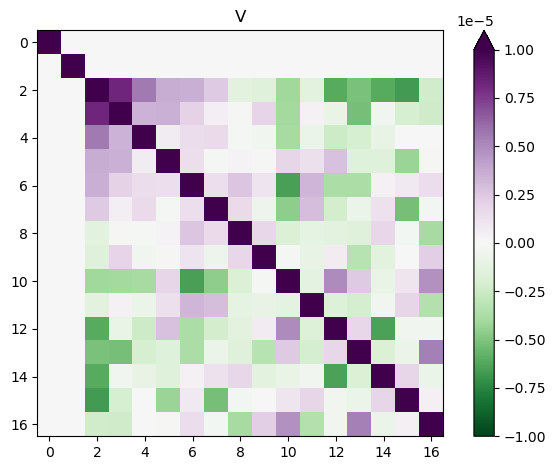

In [125]:
plt.figure(tight_layout=True)

plt.imshow(V, origin='upper', cmap='PRGn_r', vmin=-0.00001, vmax=0.00001)

plt.title('V')

plt.colorbar(extend='max');

## Calculate U

In [118]:
U = np.matmul(np.matmul(A.T, V), A)

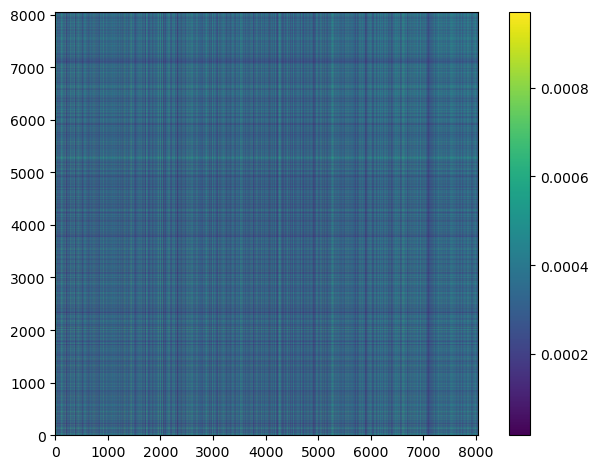

In [119]:
plt.figure(tight_layout=True)

# plt.imshow(U, origin='lower', cmap='PRGn_r', vmin=-2e-4, vmax=2e-4)
plt.imshow(U, origin='lower')

plt.colorbar();